In [2]:
import polars as pl
import pandas as pd
import numpy as np
from itertools import combinations
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.preprocessing import LabelEncoder
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
for f in os.listdir("/content/drive/MyDrive/Esports_project"):
  print (f)

Esports_Predictor.ipynb
Dataset
Parquets


In [4]:
base = "/content/drive/MyDrive/Esports_project"
final_draft = pl.read_parquet(f"{base}/Parquets/final_draft.parquet")
champ_wr    = pl.read_parquet(f"{base}/Parquets/champ_winrates.parquet")
pairs       = pl.read_parquet(f"{base}/Parquets/champ_synergies.parquet")

print(final_draft.shape)
print(final_draft.columns)
print(final_draft.head(3))

(4592, 32)
['gameid', 'blue_top', 'blue_jng', 'blue_mid', 'blue_bot', 'blue_sup', 'red_top', 'red_jng', 'red_mid', 'red_bot', 'red_sup', 'league', 'year', 'split', 'playoffs', 'date', 'patch', 'blue_team', 'blue_firstPick', 'blue_ban1', 'blue_ban2', 'blue_ban3', 'blue_ban4', 'blue_ban5', 'red_team', 'red_firstPick', 'red_ban1', 'red_ban2', 'red_ban3', 'red_ban4', 'red_ban5', 'blue_win']
shape: (3, 32)
┌────────────────┬──────────┬───────────┬──────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ gameid         ┆ blue_top ┆ blue_jng  ┆ blue_mid ┆ … ┆ red_ban3 ┆ red_ban4 ┆ red_ban5 ┆ blue_win │
│ ---            ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str            ┆ str      ┆ str       ┆ str      ┆   ┆ str      ┆ str      ┆ str      ┆ i64      │
╞════════════════╪══════════╪═══════════╪══════════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ LOLTMNT05_1710 ┆ Gnar     ┆ Xin Zhao  ┆ Ahri     ┆ … ┆ Syndra   ┆ Alistar  ┆ Orianna  ┆ 

In [5]:
df = final_draft.to_pandas()

print(df.shape)
print(df["blue_win"].value_counts())
print(df.isnull().sum().sort_values(ascending=False).head(20))

(4592, 32)
blue_win
1    2417
0    2175
Name: count, dtype: int64
split             715
blue_ban5          49
red_ban4           49
red_ban5           48
blue_ban4          45
red_ban1           42
blue_ban1          41
blue_ban3          41
red_ban2           39
red_ban3           38
blue_ban2          35
blue_firstPick     24
red_firstPick      24
gameid              0
blue_jng            0
blue_top            0
date                0
playoffs            0
year                0
league              0
dtype: int64


In [6]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Earliest match:", df["date"].min())
print("Latest match:",   df["date"].max())

Earliest match: 2026-01-08 17:08:27
Latest match: 2026-05-15 11:49:40


In [7]:
# Layer 1 Win rate features
# Join Xinyu's champ_winrates onto each of the 10 champion columns. This give the model a numeric signal for each pick
wr_map = dict(zip(champ_wr["champion"].to_list(), champ_wr["win_rate"].to_list()))
global_avg_wr = champ_wr["win_rate"].mean()

role_cols = ["blue_top","blue_jng","blue_mid","blue_bot","blue_sup",
             "red_top", "red_jng", "red_mid", "red_bot", "red_sup"]

for col in role_cols:
    df[f"{col}_wr"] = df[col].map(wr_map).fillna(global_avg_wr)

print(df[["blue_top","blue_top_wr","red_top","red_top_wr"]].head(5))

   blue_top  blue_top_wr  red_top  red_top_wr
0      Gnar     0.551765   Zaahen    0.534749
1  Renekton     0.511509   Zaahen    0.534749
2   Ambessa     0.491820  K'Sante    0.424976
3  Cho'Gath     0.350000  K'Sante    0.424976
4   Ambessa     0.491820   Rumble    0.543330


In [8]:
# Layer 2 Synergy score per team
# For each match, look up every same-team champion pair in Xinyu's synergy table and average them.
pair_map = {}
for row in pairs.to_dicts():
    key = tuple(sorted([row["champion"], row["champ2"]]))
    pair_map[key] = row["pair_win_rate"]

def team_synergy_score(champs):
    scores = []
    valid = [c for c in champs if pd.notna(c)]
    for c1, c2 in combinations(valid, 2):
        key = tuple(sorted([c1, c2]))
        if key in pair_map:
            scores.append(pair_map[key])
    return np.mean(scores) if scores else 0.5

blue_roles = ["blue_top","blue_jng","blue_mid","blue_bot","blue_sup"]
red_roles  = ["red_top", "red_jng", "red_mid", "red_bot", "red_sup"]

df["blue_synergy"] = df[blue_roles].apply(lambda row: team_synergy_score(row.tolist()), axis=1)
df["red_synergy"]  = df[red_roles].apply(lambda row: team_synergy_score(row.tolist()), axis=1)

print(df[["blue_synergy","red_synergy"]].describe())

       blue_synergy  red_synergy
count   4592.000000  4592.000000
mean       0.503584     0.499454
std        0.051053     0.052206
min        0.207792     0.142857
25%        0.471774     0.467015
50%        0.503696     0.499756
75%        0.534734     0.532539
max        0.727479     0.714381


In [9]:
# Layer 3 Aggregate win rate per team
# One number summarizing how strong each team's picks are overall.
df["blue_team_avg_wr"] = df[[f"{r}_wr" for r in blue_roles]].mean(axis=1)
df["red_team_avg_wr"]  = df[[f"{r}_wr" for r in red_roles]].mean(axis=1)

# Difference feature — positive means Blue has stronger picks
df["wr_diff"] = df["blue_team_avg_wr"] - df["red_team_avg_wr"]
df["synergy_diff"] = df["blue_synergy"] - df["red_synergy"]

In [10]:
# Encode categorical columns
cat_cols = role_cols + ["patch", "league", "blue_team", "red_team"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].fillna("UNKNOWN").astype(str))
    encoders[col] = le

print("Encoded columns added.")

Encoded columns added.


In [11]:
# Define feature list and target
# Champion encodings (categorical)
champ_enc_cols = [c + "_enc" for c in role_cols]

# Categorical context
context_enc_cols = ["patch_enc", "league_enc"]

# Numeric features
numeric_cols = (
    [f"{r}_wr" for r in blue_roles + red_roles] +
    ["blue_synergy", "red_synergy",
     "blue_team_avg_wr", "red_team_avg_wr",
     "wr_diff", "synergy_diff"]
)

feature_cols = champ_enc_cols + context_enc_cols + numeric_cols
target_col   = "blue_win"

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 28
['blue_top_enc', 'blue_jng_enc', 'blue_mid_enc', 'blue_bot_enc', 'blue_sup_enc', 'red_top_enc', 'red_jng_enc', 'red_mid_enc', 'red_bot_enc', 'red_sup_enc', 'patch_enc', 'league_enc', 'blue_top_wr', 'blue_jng_wr', 'blue_mid_wr', 'blue_bot_wr', 'blue_sup_wr', 'red_top_wr', 'red_jng_wr', 'red_mid_wr', 'red_bot_wr', 'red_sup_wr', 'blue_synergy', 'red_synergy', 'blue_team_avg_wr', 'red_team_avg_wr', 'wr_diff', 'synergy_diff']


In [12]:
# Temporal train/ validation split
cutoff = int(len(df) * 0.8)

train_df = df.iloc[:cutoff].copy()
val_df   = df.iloc[cutoff:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

print(f"Train: {len(train_df)} rows  |  Val: {len(val_df)} rows")
print(f"Train date range: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Val   date range: {val_df['date'].min()}  → {val_df['date'].max()}")

Train: 3673 rows  |  Val: 919 rows
Train date range: 2026-01-08 17:08:27 → 2026-04-27 10:36:42
Val   date range: 2026-04-27 10:39:22  → 2026-05-15 11:49:40


In [21]:
# Mark categorical columns BEFORE fitting
for col in champ_enc_cols + context_enc_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")

# Remove categorical_feature from the classifier
base_model = lgb.LGBMClassifier(
    objective="binary",
    metric="binary_logloss",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    verbose=-1
)

calibrated_model = CalibratedClassifierCV(
    base_model,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train, y_train)
print("Training complete.")

/tmp/ipykernel_7186/4142384833.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype("category")
/tmp/ipykernel_7186/4142384833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col]   = X_val[col].astype("category")


Training complete.


In [22]:
# Evaluate with Brier Score and Log-Loss
probs = calibrated_model.predict_proba(X_val)[:, 1]

brier = brier_score_loss(y_val, probs)
logloss = log_loss(y_val, probs)

print(f"Brier Score : {brier:.4f}   (random baseline = 0.2500)")
print(f"Log-Loss    : {logloss:.4f}   (random baseline = 0.6931)")

Brier Score : 0.1646   (random baseline = 0.2500)
Log-Loss    : 0.4989   (random baseline = 0.6931)


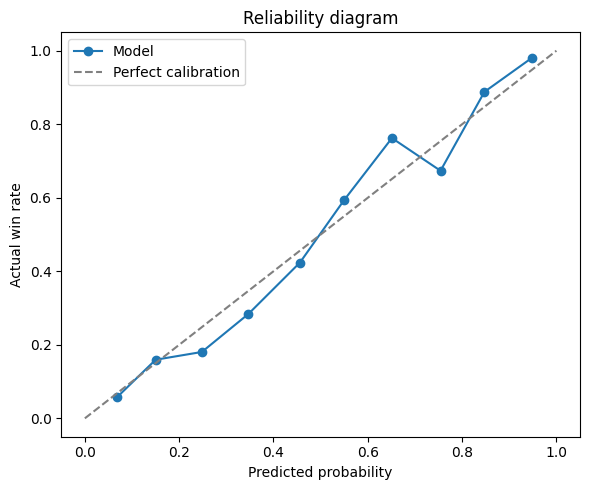

In [23]:
# Reliability diagram (calibration curve)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fraction_pos, mean_pred = calibration_curve(y_val, probs, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(mean_pred, fraction_pos, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Actual win rate")
plt.title("Reliability diagram")
plt.legend()
plt.tight_layout()
plt.savefig(f"{base}/calibration_curve.png", dpi=150)
plt.show()

In [24]:
# Save the model
import pickle

with open(f"{base}/calibrated_model.pkl", "wb") as f:
    pickle.dump(calibrated_model, f)

# Also save the feature list and encoders — Fariq and Member D will need these
with open(f"{base}/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

with open(f"{base}/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Saved: calibrated_model.pkl, feature_cols.pkl, encoders.pkl")

Saved: calibrated_model.pkl, feature_cols.pkl, encoders.pkl


In [20]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/MemberB(Liam).ipynb",
    "/content/drive/MyDrive/Esports_project/MemberB(Liam).ipynb"
)

print("Notebook saved to Esports_project folder.")